## Analyze only the users, not the admins.
The font size and fig size should remain the same.
For each hour, calculate the average number of commits on working days and weekends. If there were no commits in an hour, do not use it to calculate the average. Use these values for your graph. For example: Monday, 17–18: 5 commits; Tuesday, 17–18: 6 commits; Wednesday, 17–18: 7 commits.
Choose a palette you really enjoy. You do not have to replicate the one from the graph above.
At the end of your Jupyter Notebook, create a Markdown cell and insert the following question:
"Is the dynamic different on working days and weekends?" For the answer, include the hour when the number of commits is largest during working days and the hour when it is largest during the weekend.

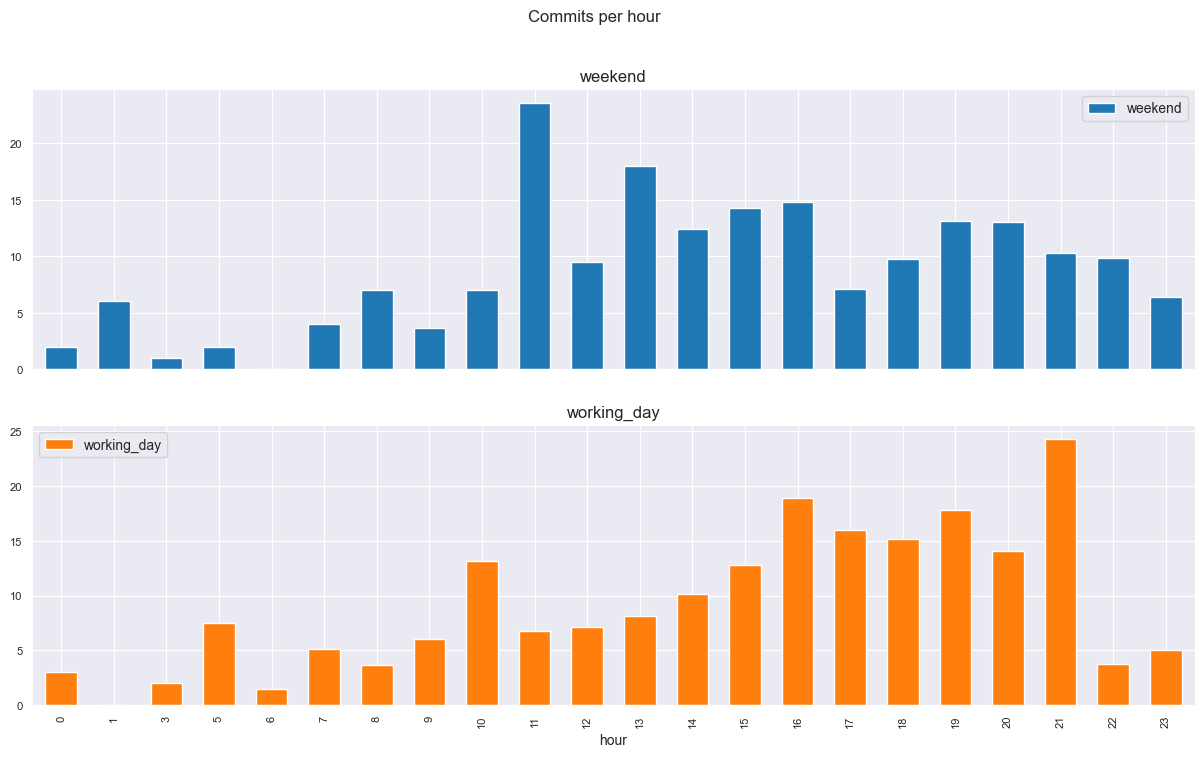

In [1]:
from itertools import count

import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/checking-logs.sqlite')
query = """
SELECT timestamp AS date
FROM checker
WHERE uid LIKE 'user_%' 
"""
all_days = pd.read_sql_query(query, conn)
all_days['date']= pd.to_datetime(all_days['date'])
all_days['hour'] = all_days['date'].dt.hour
all_days['week_day'] = all_days['date'].dt.weekday

all_days['day_type'] = all_days['week_day'].apply(lambda x: 'weekend' if x >=5 else 'working_day')


grouped = all_days.groupby([all_days['date'].dt.date,'hour','day_type']).size().reset_index(name="commits_cnt")

avg_hourly = (
    grouped
    .groupby(["hour", "day_type"])["commits_cnt"]
    .mean()
    .reset_index(name="avg_commits")
)
result = avg_hourly.pivot(index="hour", columns="day_type", values="avg_commits")

result.plot(
    kind='bar',
    subplots=True,
    figsize=(15, 8),
    width=0.6,
    title='Commits per hour',
    fontsize=8,
    rot=90
)

conn.close()


## Отличается ли динамика в рабочие дни и выходные?

Ответ: максимум в рабочие дни: 21-ый час, максимум в выходные: 11-ый час